In [1]:
! pip uninstall -y numpy scikit-surprise
! pip install numpy==1.24.4
! pip install cython

Found existing installation: numpy 1.24.4
Uninstalling numpy-1.24.4:
  Successfully uninstalled numpy-1.24.4
Found existing installation: scikit-surprise 1.1.3
Uninstalling scikit-surprise-1.1.3:
  Successfully uninstalled scikit-surprise-1.1.3
  Using cached numpy-1.24.4-cp310-cp310-win_amd64.whl.metadata (5.6 kB)
Using cached numpy-1.24.4-cp310-cp310-win_amd64.whl (14.8 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires numpy>=1.26.0, but you have numpy 1.24.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
! pip install scikit-surprise==1.1.3
! pip install mlxtend
! pip install implicit
! pip install graphviz


  Using cached scikit_surprise-1.1.3-cp310-cp310-win_amd64.whl



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# Others
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

RANDOM_STATE = 42

## Load data

In [4]:
# Load data
orders = pd.read_csv("data/olist_orders_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
category = pd.read_csv("data/product_category_name_translation.csv")
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")

print("Loaded all datasets")


Loaded all datasets


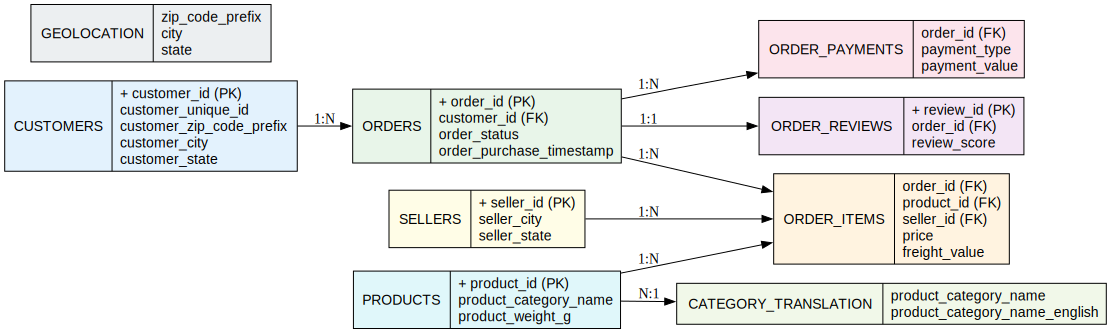

In [5]:
from graphviz import Digraph

erd = Digraph('Olist_ERD', format='png')
erd.attr(rankdir='LR', bgcolor='white')

# Style chung
erd.attr('node', shape='record', style='filled', fontname='Helvetica')


erd.node('customers', '''{
CUSTOMERS |
+ customer_id (PK)\\l
customer_unique_id\\l
customer_zip_code_prefix\\l
customer_city\\l
customer_state\\l
}''', fillcolor='#E3F2FD')

erd.node('orders', '''{
ORDERS |
+ order_id (PK)\\l
customer_id (FK)\\l
order_status\\l
order_purchase_timestamp\\l
}''', fillcolor='#E8F5E9')

erd.node('order_items', '''{
ORDER_ITEMS |
order_id (FK)\\l
product_id (FK)\\l
seller_id (FK)\\l
price\\l
freight_value\\l
}''', fillcolor='#FFF3E0')

erd.node('order_payments', '''{
ORDER_PAYMENTS |
order_id (FK)\\l
payment_type\\l
payment_value\\l
}''', fillcolor='#FCE4EC')

erd.node('order_reviews', '''{
ORDER_REVIEWS |
+ review_id (PK)\\l
order_id (FK)\\l
review_score\\l
}''', fillcolor='#F3E5F5')

erd.node('products', '''{
PRODUCTS |
+ product_id (PK)\\l
product_category_name\\l
product_weight_g\\l
}''', fillcolor='#E0F7FA')

erd.node('sellers', '''{
SELLERS |
+ seller_id (PK)\\l
seller_city\\l
seller_state\\l
}''', fillcolor='#FFFDE7')

erd.node('geolocation', '''{
GEOLOCATION |
zip_code_prefix\\l
city\\l
state\\l
}''', fillcolor='#ECEFF1')

erd.node('category', '''{
CATEGORY_TRANSLATION |
product_category_name\\l
product_category_name_english\\l
}''', fillcolor='#F1F8E9')



erd.edge('customers', 'orders', label='1:N', color='black')
erd.edge('orders', 'order_items', label='1:N')
erd.edge('orders', 'order_payments', label='1:N')
erd.edge('orders', 'order_reviews', label='1:1')

erd.edge('products', 'order_items', label='1:N')
erd.edge('sellers', 'order_items', label='1:N')

erd.edge('products', 'category', label='N:1')



erd.render('olist_erd_pro', view=True)

erd

## EDA

In [6]:
# Data Processing
print(orders.head())
print(orders.info())
print(orders.describe())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [7]:
# Missing values
orders.isnull().sum()
orders.isnull().mean() * 100

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.160899
order_delivered_carrier_date     1.793023
order_delivered_customer_date    2.981668
order_estimated_delivery_date    0.000000
dtype: float64

In [8]:
# Missing values
missing = orders.isnull().sum()
print(missing[missing > 0])

order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64


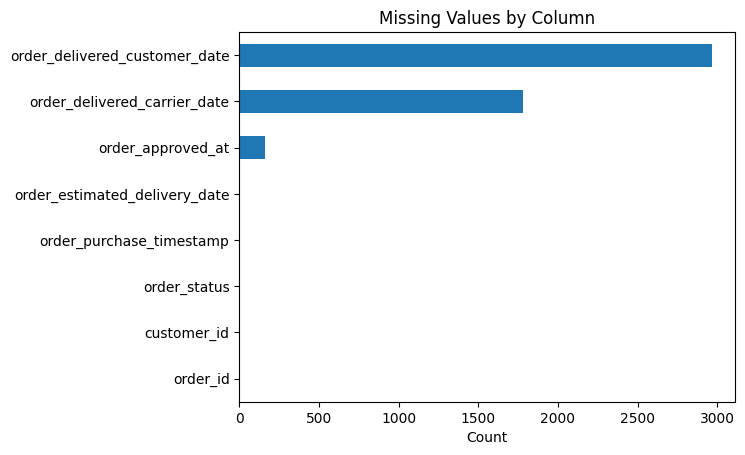

In [9]:
missing.sort_values().plot(kind='barh')
plt.title("Missing Values by Column")
plt.xlabel("Count")
plt.show()


review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


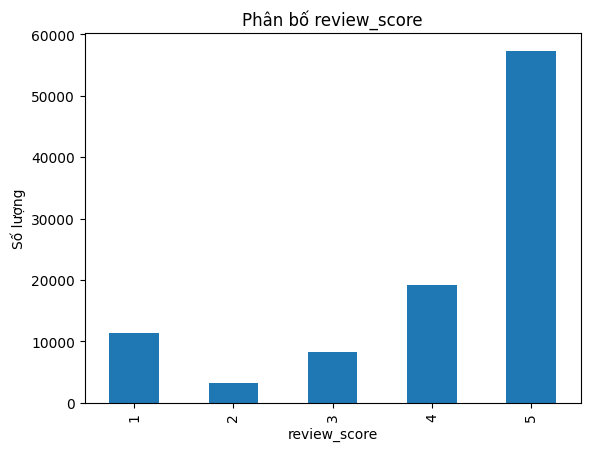

In [10]:
# Distribution
review_dist = reviews["review_score"].value_counts().sort_index()
print(review_dist)

review_dist.plot(kind="bar")
plt.title("Phân bố review_score")
plt.xlabel("review_score")
plt.ylabel("Số lượng")
plt.show()

In [11]:
df_geo_clean = geolocation.groupby("geolocation_zip_code_prefix").agg({
   "geolocation_lat": "mean",
   "geolocation_lng": "mean"
}).round(4).reset_index()

In [12]:
# Merge Data
df = orders.merge(customers, on="customer_id", how="left") \
           .merge(order_items, on="order_id", how="left") \
           .merge(products, on="product_id", how="left") \
           .merge(sellers, on="seller_id", how="left") \
           .merge(reviews, on="order_id", how="left") \
           .merge(payments, on="order_id", how="left") \
           .merge(category, on="product_category_name", how="left") \
           .merge(df_geo_clean, left_on="customer_zip_code_prefix", 
                  right_on="geolocation_zip_code_prefix", how="left")

print("Data shape:", df.shape)

Data shape: (119143, 43)


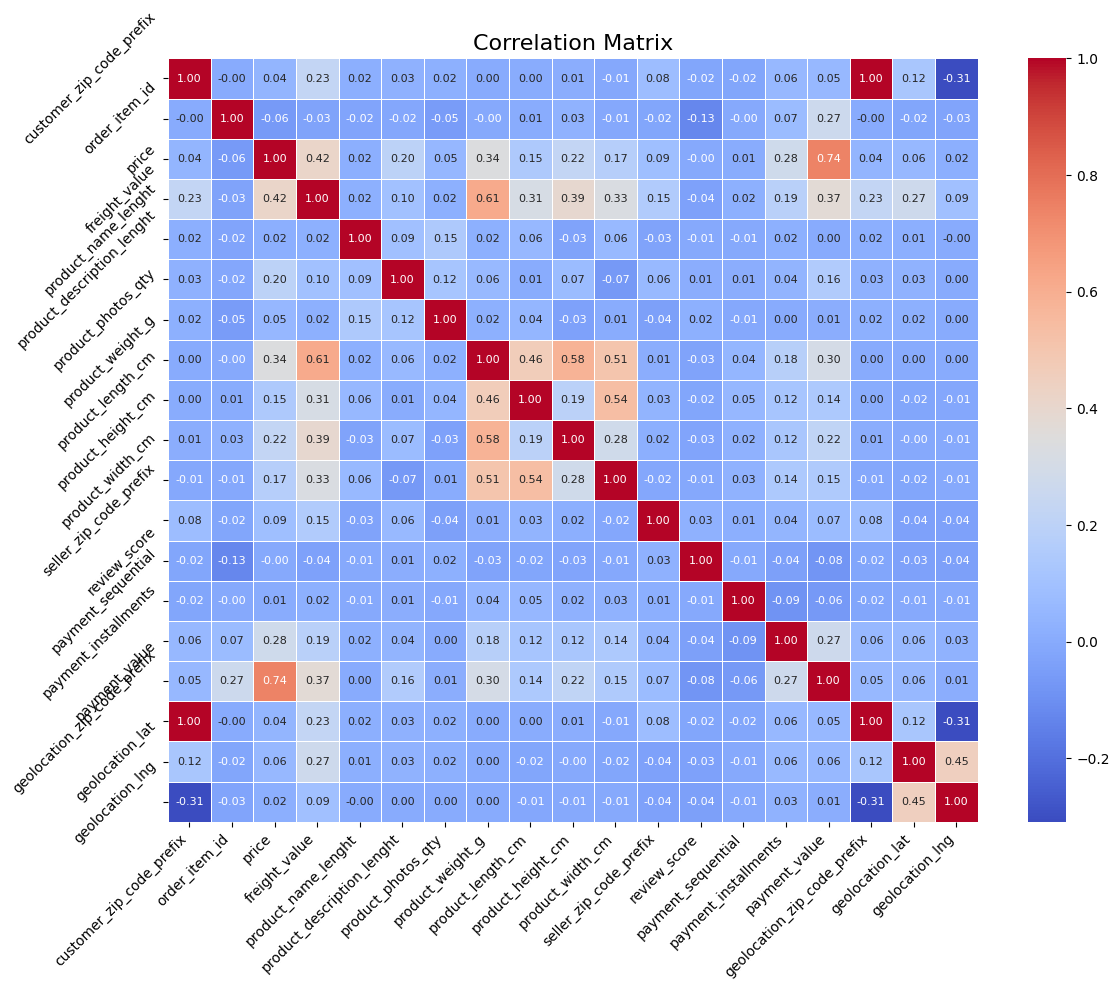

In [13]:
# Ma trận tương quan
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure and an axes object with a specified size
plt.figure(figsize=(12, 10))

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

## Cleaning 

In [14]:
# fix missing
# Text
df["review_comment_message"] = df["review_comment_message"].fillna("No review")

# Category
df["product_category_name_english"] = df["product_category_name_english"].fillna("unknown")

# Numeric
num_cols = ["price", "freight_value", "payment_value"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())


In [15]:
# Drop NA target
df = df.dropna(subset=["review_score"])

In [16]:
# Convert data
date_cols = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "order_purchase_timestamp",
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

## Feature Engineering

In [17]:
#RFM

today = df["order_purchase_timestamp"].max()

rfm = df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (today - x.max()).days,
    "order_id": "count",
    "payment_value": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,cluster
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,1
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,1
0000f46a3911fa3c0805444483337064,585,1,86.22,0
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,0
0004aac84e0df4da2b147fca70cf8255,336,1,196.89,0


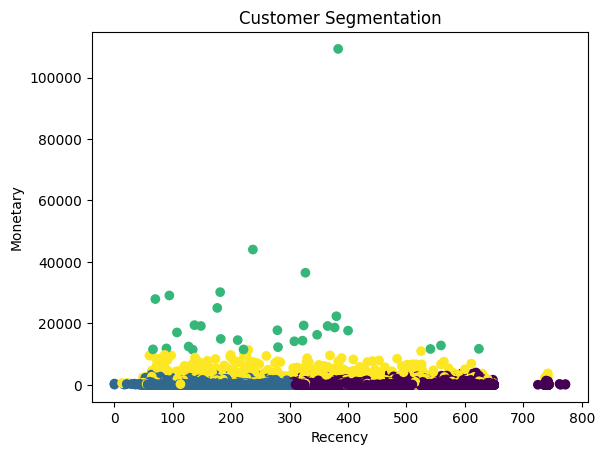

In [18]:
plt.figure()
plt.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["cluster"])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segmentation")
plt.show()

In [19]:
# Delivery
df["delivery_delay_days"] = (
   df["order_delivered_customer_date"] -
   df["order_estimated_delivery_date"]
).dt.days
df["delivery_delay_days"].head()

0    -8.0
1    -8.0
2    -8.0
3    -6.0
4   -18.0
Name: delivery_delay_days, dtype: float64

In [20]:
# =========================
# NUMERIC FEATURES
# =========================
X_numeric = df[["price", "freight_value", "payment_value"]]

# scale (QUAN TRỌNG vì dùng chi2)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# =========================
# TF-IDF
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

tfidf = TfidfVectorizer(max_features=3000)
X_text = tfidf.fit_transform(df["review_comment_message"])

# =========================
# COMBINE
# =========================
X_full = hstack([X_numeric_scaled, X_text])

## Target + Split

In [21]:
df["target"] = df["review_score"].apply(lambda x: 1 if x >= 4 else 0)

features = ["price", "freight_value", "payment_value", "payment_type"]

X = df[features]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

## Pipeline

In [22]:
num_features = ["price", "freight_value", "payment_value"]
cat_features = ["payment_type"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_features)
])

pipe = Pipeline([
        ("preprocess", preprocessor),
        ("select", SelectKBest(score_func=f_classif, k=5)),
        ("model", LogisticRegression(max_iter=1000))
    ])
    
    
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('select', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:

# Save models

joblib.dump(pipe, "pipeline.pkl")

loaded_model = joblib.load("pipeline.pkl")

print("Đã lưu và tải lại Pipeline thành công!")

Đã lưu và tải lại Pipeline thành công!


## Classification Models

In [24]:
models = {
    "Logistic": LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42),
    "NaiveBayes": GaussianNB(),
    "SVC": LinearSVC(max_iter=2000),   
    "GradientBoost": GradientBoostingClassifier(n_estimators=50, random_state=42)
}

## Train & Evaluation

In [25]:
from sklearn.feature_selection import f_classif

results = []

for name, model in models.items():
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("select", SelectKBest(score_func=f_classif, k=5)),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1
    })
    
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))

df_results = pd.DataFrame(results)
df_results


Logistic
[[   25  5872]
 [   18 17715]]

RandomForest
[[ 2031  3866]
 [ 1814 15919]]

NaiveBayes
[[   65  5832]
 [   60 17673]]

SVC
[[   16  5881]
 [   14 17719]]

GradientBoost
[[  168  5729]
 [   61 17672]]


,Model,Accuracy,F1
0,Logistic,0.750741,0.857454
1,RandomForest,0.759628,0.848606
2,NaiveBayes,0.750656,0.857122
3,SVC,0.750529,0.857378
4,GradientBoost,0.754972,0.859241


## ROC Curve

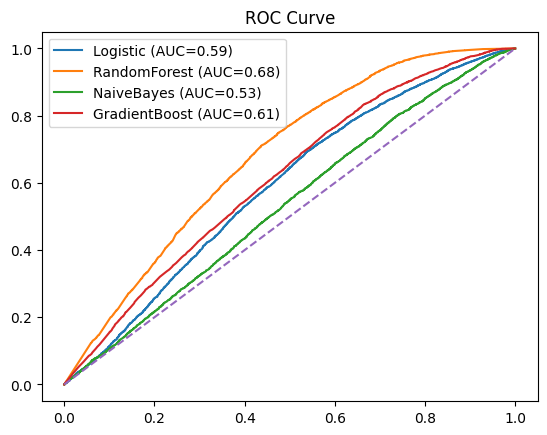

In [26]:
plt.figure()

for name, model in models.items():
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    if hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:,1]
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.legend()
plt.title("ROC Curve")
plt.show()

## Regression

In [ ]:
# =========================
# 1. IMPORT
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# =========================
# 2. DATA
# =========================
features_reg = ["price", "payment_value"]
target_reg = "freight_value"

X = df[features_reg]
y = df[target_reg]

# =========================
# 3. SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. CLEAN NaN
# =========================
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

# =========================
# 5. MODELS
# =========================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = []

# =========================
# 6. TRAIN + EVALUATE
# =========================
for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

# =========================
# 7. RESULT TABLE
# =========================
df_results = pd.DataFrame(results).sort_values(by="RMSE")

print("\n=== Regression Model Comparison ===")
display(df_results)

# =========================
# 8. BEST MODEL
# =========================
best_model_name = df_results.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")

# =========================
# 9. VISUALIZATION
# =========================
y_pred = best_model.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 1. Actual vs Predicted
ax[0].scatter(y_test, y_pred, alpha=0.3)
ax[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[0].set_title("Actual vs Predicted")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")

# 2. Residuals
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()


=== Regression Model Comparison ===


,Model,RMSE,MAE,R2
2,Random Forest,7.947616,1.937435,0.747362
1,Decision Tree,9.696066,1.958774,0.623976
0,Linear Regression,14.237230,7.634582,0.189272



Best Model: Random Forest


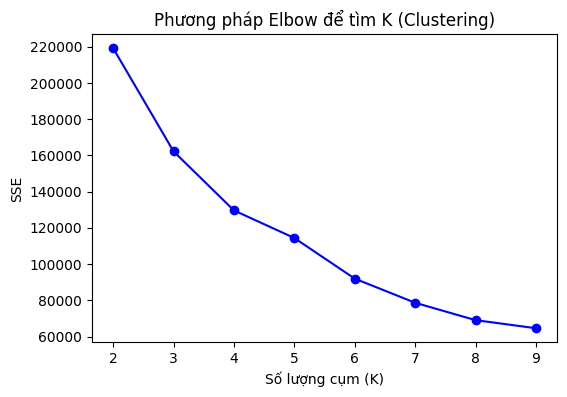

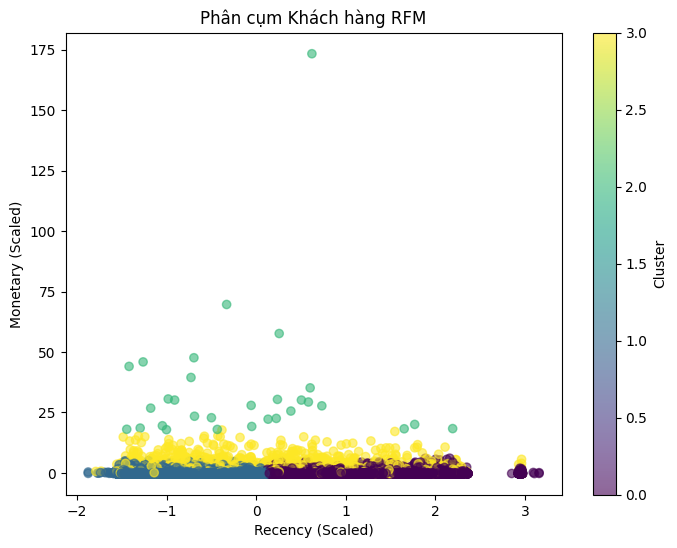

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa dữ liệu RFM
rfm_scaled = StandardScaler().fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# 1. Vẽ Elbow Method tìm K
sse = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, sse, marker='o', color='b')
plt.title('Phương pháp Elbow để tìm K (Clustering)')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('SSE')
plt.show()

# 2. Vẽ Scatter Plot với K=4 (để minh họa cho K đã chọn)
kmeans_opt = KMeans(n_clusters=4, random_state=42)
rfm['kmeans_cluster'] = kmeans_opt.fit_predict(rfm_scaled)

plt.figure(figsize=(8, 6))
# Vẽ cột 0 (Recency) và cột 2 (Monetary)
scatter = plt.scatter(rfm_scaled[:, 0], rfm_scaled[:, 2], c=rfm['kmeans_cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Recency (Scaled)')
plt.ylabel('Monetary (Scaled)')
plt.title('Phân cụm Khách hàng RFM')
plt.show()

## Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=4)
rfm["cluster"] = kmeans.fit_predict(rfm)

score = silhouette_score(rfm[["Recency","Frequency","Monetary"]], rfm["cluster"])
print("Silhouette:", score)
print("\nCluster counts:\n", rfm["cluster"].value_counts())

Silhouette: 0.8532708415681428

Cluster counts:
 cluster
0    93579
1     1761
2       39
3        1
Name: count, dtype: int64


KMeans silhouette: 0.5798429473046968
GMM silhouette: 0.6013722826525505


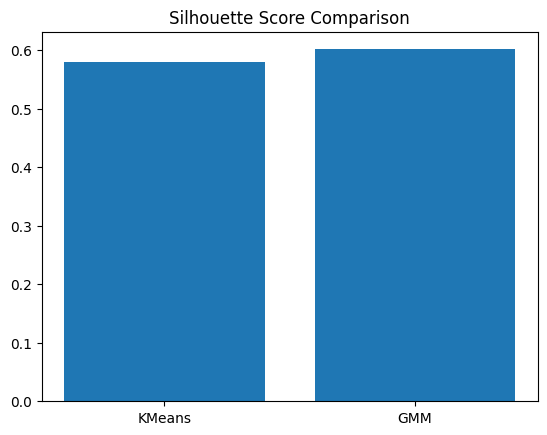

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# ======================
# KMEANS
# ======================
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(rfm_scaled)

score_kmeans = silhouette_score(rfm_scaled, labels_kmeans)

# ======================
# GMM
# ======================
gmm = GaussianMixture(n_components=4, random_state=42)
labels_gmm = gmm.fit_predict(rfm_scaled)

score_gmm = silhouette_score(rfm_scaled, labels_gmm)

print('KMeans silhouette:', score_kmeans)
print('GMM silhouette:', score_gmm)

# ======================
# PLOT
# ======================
import matplotlib.pyplot as plt

scores = {
    "KMeans": score_kmeans,
    "GMM": score_gmm
}

plt.figure()
plt.bar(scores.keys(), scores.values())
plt.title("Silhouette Score Comparison")
plt.show()

## Hyperparameter Tuning

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

num_cols = ["price","freight_value","payment_value"]
cat_cols = ["payment_type"]

preprocessor = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier())
])

param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [5, 10]
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring="f1")

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

ValueError: 
All the 12 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\indexes\base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'freight_value'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\_indexing.py", line 443, in _get_column_indices
    col_idx = all_columns.get_loc(col)
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\indexes\base.py", line 3819, in get_loc
    raise KeyError(key) from err
KeyError: 'freight_value'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py", line 655, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py", line 589, in _fit
    X, fitted_transformer = fit_transform_one_cached(
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\memory.py", line 326, in __call__
    return self.func(*args, **kwargs)
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py", line 1540, in _fit_transform_one
    res = transformer.fit_transform(X, y, **params.get("fit_transform", {}))
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\_set_output.py", line 316, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\compose\_column_transformer.py", line 988, in fit_transform
    self._validate_column_callables(X)
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\compose\_column_transformer.py", line 541, in _validate_column_callables
    transformer_to_input_indices[name] = _get_column_indices(X, columns)
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\_indexing.py", line 451, in _get_column_indices
    raise ValueError("A given column is not a column of the dataframe") from e
ValueError: A given column is not a column of the dataframe


## Recommendation

In [ ]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate

rating_df = df[["customer_unique_id", "product_id", "review_score"]].dropna()

reader = Reader(rating_scale=(1,5))
data = Dataset.load_from_df(rating_df, reader)

model = SVD()

results = cross_validate(model, data, measures=["RMSE","MAE"], cv=3)

print(results)

{'test_rmse': array([1.24636386, 1.2537329 , 1.2633185 ]), 'test_mae': array([0.97532955, 0.98201696, 0.98549411]), 'fit_time': (2.841155767440796, 2.8133420944213867, 2.889768123626709), 'test_time': (0.4399247169494629, 0.46862292289733887, 0.5086543560028076)}


In [ ]:
model = SVD(random_state=42)

model.fit(trainset)

user_id = str(rating_df["customer_unique_id"].iloc[0])

items = rating_df["product_id"].unique()

purchased = rating_df[rating_df["customer_unique_id"] == user_id]["product_id"]

preds = [
    model.predict(user_id, item)
    for item in items
    if item not in purchased.values
]

top_n = sorted(preds, key=lambda x: x.est, reverse=True)[:10]

print("\nTop recommendations (SVD):")
for item in top_n:
    print(item.iid, round(item.est, 2))

NameError: name 'SVD' is not defined

## FP-GROWTH

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt

# CLEAN
df_fp = df.dropna(subset=["product_id"]).copy()
df_fp["product_id"] = df_fp["product_id"].astype(str)

# TRANSACTIONS
transactions = df_fp.groupby("order_id")["product_id"] \
    .apply(lambda x: list(set(x))) \
    .tolist()

transactions = [t for t in transactions if len(t) >= 2]

# ENCODE
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_trans = pd.DataFrame(te_array, columns=te.columns_)

print("Basket:", df_trans.shape)


freq_items = fpgrowth(
    df_trans,
    min_support=0.001,  
    use_colnames=True
)

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.01   
)

print("Total Rules:", len(rules))
print(rules.head())

rules_plot = rules[
    (rules["lift"] > 1) & 
    (rules["confidence"] > 0.2)
]

print("Basket:", df_trans.shape)
print("Total Rules:", len(rules))
print(rules.head())




Basket: (3197, 4844)
Total Rules: 58
                          antecedents                         consequents  \
0  (060cb19345d90064d1015407193c233d)  (98d61056e0568ba048e5d78038790e77)   
1  (98d61056e0568ba048e5d78038790e77)  (060cb19345d90064d1015407193c233d)   
2  (f4d705aa95ccca448e5b0deb6e5290ba)  (c211ff3068fcd2f8898192976d8b3a32)   
3  (c211ff3068fcd2f8898192976d8b3a32)  (f4d705aa95ccca448e5b0deb6e5290ba)   
4  (422879e10f46682990de24d770e7f83d)  (53759a2ecddad2bb87a079a1f1519f73)   

   antecedent support  consequent support   support  confidence        lift  \
0            0.001877            0.003128  0.001877    1.000000  319.700000   
1            0.003128            0.001877  0.001877    0.600000  319.700000   
2            0.002190            0.002815  0.001251    0.571429  202.984127   
3            0.002815            0.002190  0.001251    0.444444  202.984127   
4            0.009697            0.008758  0.001877    0.193548   22.099078   

   representativity  leve

In [ ]:
strong_rules = rules[
    (rules['confidence'] > 0.1) &
    (rules['lift'] > 1)
]

print("\nStrong Rules:")
print(strong_rules[['antecedents', 'consequents', 'confidence', 'lift']])


Strong Rules:
                           antecedents                         consequents  \
0   (060cb19345d90064d1015407193c233d)  (98d61056e0568ba048e5d78038790e77)   
1   (98d61056e0568ba048e5d78038790e77)  (060cb19345d90064d1015407193c233d)   
2   (f4d705aa95ccca448e5b0deb6e5290ba)  (c211ff3068fcd2f8898192976d8b3a32)   
3   (c211ff3068fcd2f8898192976d8b3a32)  (f4d705aa95ccca448e5b0deb6e5290ba)   
4   (422879e10f46682990de24d770e7f83d)  (53759a2ecddad2bb87a079a1f1519f73)   
5   (53759a2ecddad2bb87a079a1f1519f73)  (422879e10f46682990de24d770e7f83d)   
6   (389d119b48cf3043d311335e499d9c6b)  (53759a2ecddad2bb87a079a1f1519f73)   
7   (53759a2ecddad2bb87a079a1f1519f73)  (389d119b48cf3043d311335e499d9c6b)   
8   (422879e10f46682990de24d770e7f83d)  (389d119b48cf3043d311335e499d9c6b)   
9   (389d119b48cf3043d311335e499d9c6b)  (422879e10f46682990de24d770e7f83d)   
10  (389d119b48cf3043d311335e499d9c6b)  (368c6c730842d78016ad823897a372db)   
11  (368c6c730842d78016ad823897a372db)  (389d119b

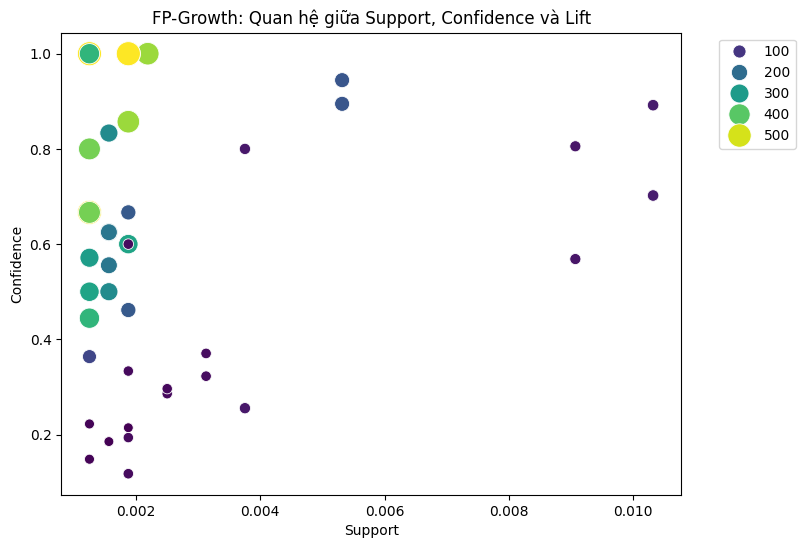

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="support", 
    y="confidence", 
    size="lift", 
    hue="lift", 
    data=rules, 
    palette="viridis", 
    sizes=(50, 300)
)
plt.title('FP-Growth: Quan hệ giữa Support, Confidence và Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

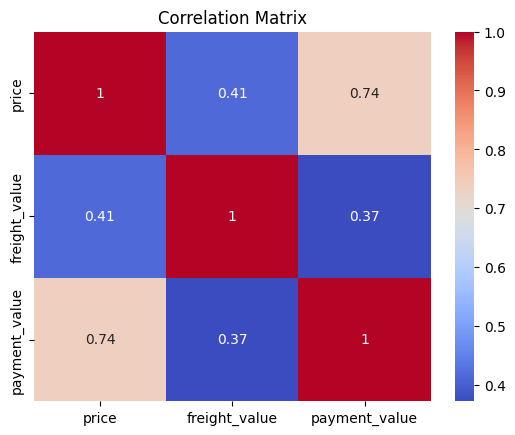

In [ ]:
# Correlation Matrix

corr = df[["price","freight_value","payment_value"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Chi-square test
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(df["payment_type"], df["target"])

chi2, p, dof, expected = chi2_contingency(cont_table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 34.12143858403628
p-value: 7.036534103109009e-07
